In [1]:
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, ACCEPTANCE_COEFFS_PATH, C9, DEFAULT_STRIDE, DEFAULT_PRE_N, DEFAULT_PRERUNS, REAL_DATA
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.managers.imperfections_diagnostics import ImperfectionsDiagnostics
from sbi_particle_physics.managers.model_diagnostics import ModelDiagnostics
from sbi_particle_physics.managers.real_data import RealData
import torch

In [2]:
device = "cpu" # this small test works on cpu
max_files = 3000
n_points = 10000
files = Backup.detect_files(DATA_DIR / "data_6")
print(f"#files found {len(files)}")
files = files[:max_files]
raw_data, raw_parameters, _ = Backup.load_data(files, device)
print(raw_data.shape)

#files found 11


Loading files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
Loading a file
torch.Size([11, 10000, 5])


In [3]:
real_raw_data = RealData.load_n_points(REAL_DATA, n_points=n_points, device=device)
print(real_raw_data[:,:].mean(dim=0))
print(real_raw_data[:,-1].mean())

Loading LHCb data (partial):   0%|          | 0/40 [00:00<?, ?it/s]

tensor([ 3.6707, -0.0128, -0.0988,  0.0674,  5.2889])
tensor(5.2889)


In [4]:
def select_closest_c9_dataset(raw_data, c9_values, C9_true):
    distances = torch.abs(c9_values - C9_true)
    idx = torch.argmin(distances).item()
    x_sim_selected = raw_data[idx]
    print(f"Selected C9 = {c9_values[idx].item():.4f} (need to be close to {C9})")
    return x_sim_selected

In [5]:
x_real = real_raw_data # Observed real
x_sim = select_closest_c9_dataset(raw_data, raw_parameters, C9) # "Full" (ie include imperfections)
x_obs = raw_data[1] # Observed but simulated
x_sim_long = raw_data[2:]

Selected C9 = 3.3864 (need to be close to 3.5699999999999994)


In [6]:
def apply_mask(x, q2_max=6.0, mB_max=5.4):
    mask = (x[:, 0] <= q2_max) & (x[:, -1] <= mB_max)
    return x[mask]

x_real = apply_mask(x_real)
x_sim = apply_mask(x_sim)
x_obs = apply_mask(x_obs)
print(f"shape x _long before masking: {x_sim_long.shape}")
x_sim_long = [apply_mask(x) for x in x_sim_long]
print(f"shape x _long after masking: {[x.shape for x in x_sim_long]}")

print(x_real.shape, x_sim.shape, x_obs.shape)

shape x _long before masking: torch.Size([9, 10000, 5])
shape x _long after masking: [torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5]), torch.Size([10000, 5])]
torch.Size([9494, 5]) torch.Size([10000, 5]) torch.Size([10000, 5])


In [7]:
def mask_columns_with_zero(x, columns_to_keep):
    y = torch.zeros_like(x)
    y[:, columns_to_keep] = x[:, columns_to_keep]
    return y

cols_to_keep = [0,1,2,3,4] # 1 ok

x_real = mask_columns_with_zero(x_real, cols_to_keep)
x_sim = mask_columns_with_zero(x_sim, cols_to_keep)
x_obs = mask_columns_with_zero(x_obs, cols_to_keep)
x_sim_long = [mask_columns_with_zero(x, cols_to_keep) for x in x_sim_long]

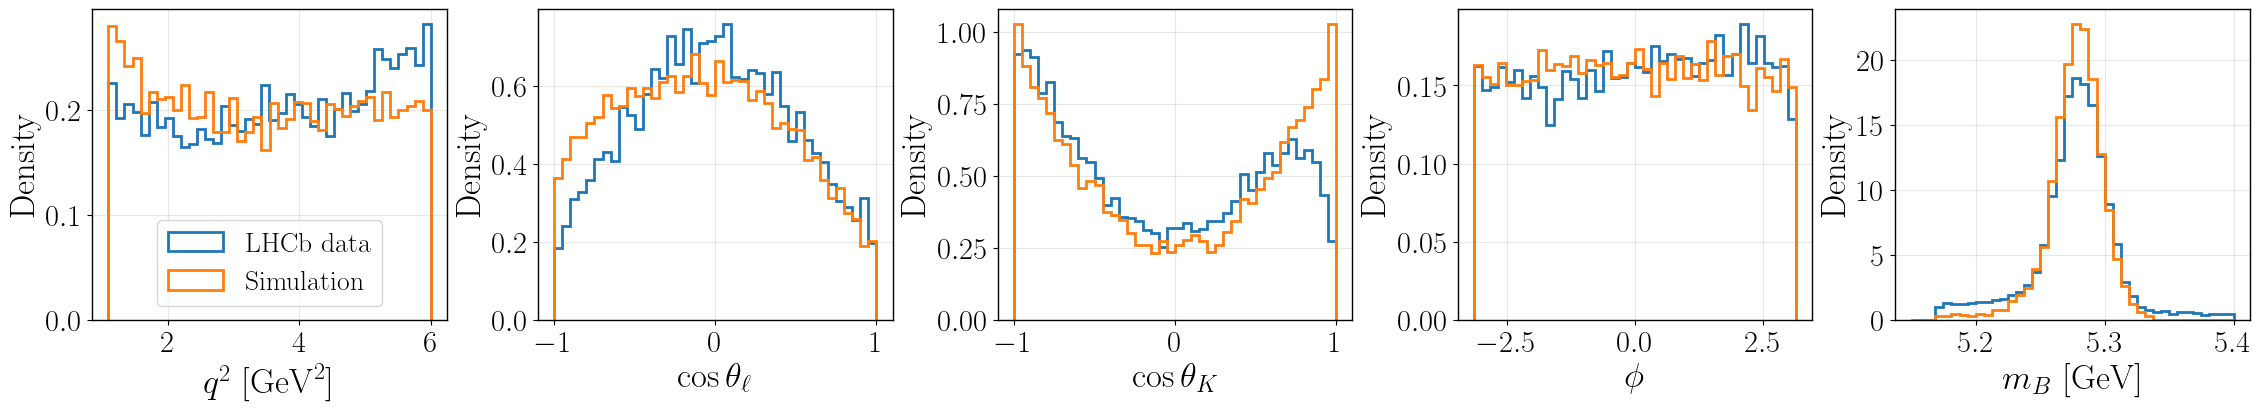

In [8]:
ImperfectionsDiagnostics.compare_real_vs_simulated(x_real, x_sim, bins=40)

In [9]:
ImperfectionsDiagnostics.chi2_test(x_sim, x_real, bins=40)

$q^2\ [\mathrm{GeV}^2]$ : chi2/ndof = 141.08/39, p = 0.000
$\cos\theta_\ell$ : chi2/ndof = 191.90/39, p = 0.000
$\cos\theta_K$ : chi2/ndof = 401.91/39, p = 0.000
$\phi$ : chi2/ndof = 47.47/39, p = 0.166
$m_B\ [\mathrm{GeV}]$ : chi2/ndof = 681.99/39, p = 0.000


 Training neural network. Epochs trained: 37p-value: 0.0000, Reject H0 (misspecified): True


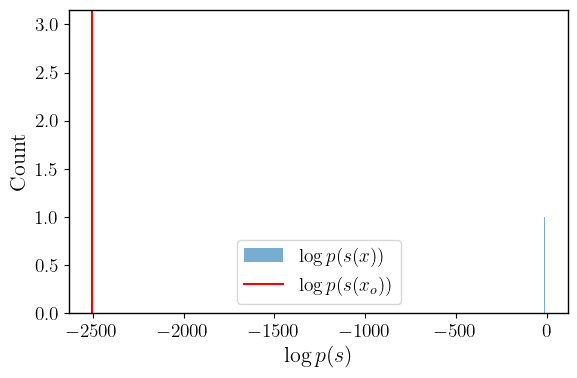

In [10]:
ModelDiagnostics.misspecification_test(x_sim_long, x_o=x_real) # <----

MMD p-value: 0.119


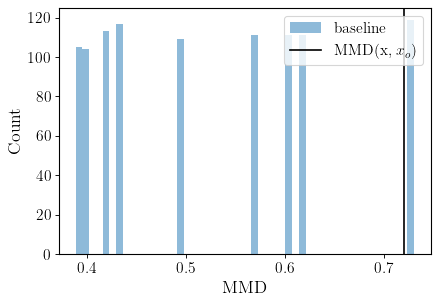

In [11]:
ModelDiagnostics.misspecification_test_mmd(x_sim_long, x_o=x_real)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)

In [12]:
ImperfectionsDiagnostics.chi2_test(x_sim, x_obs, bins=40)

$q^2\ [\mathrm{GeV}^2]$ : chi2/ndof = 31.18/39, p = 0.809
$\cos\theta_\ell$ : chi2/ndof = 27.84/39, p = 0.908
$\cos\theta_K$ : chi2/ndof = 29.98/39, p = 0.850
$\phi$ : chi2/ndof = 26.55/39, p = 0.936
$m_B\ [\mathrm{GeV}]$ : chi2/ndof = 32.55/39, p = 0.758


 Training neural network. Epochs trained: 36p-value: 0.0000, Reject H0 (misspecified): True


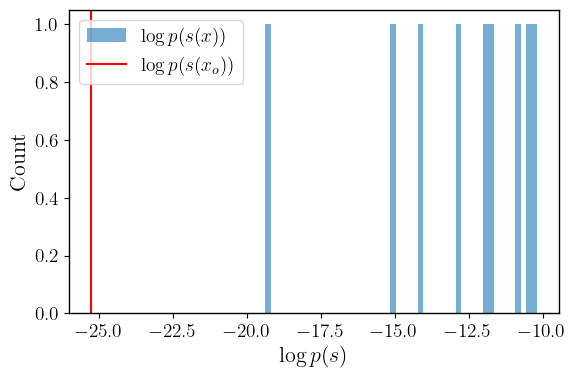

In [13]:
ModelDiagnostics.misspecification_test(x_sim_long, x_o=x_obs) # <----

MMD p-value: 0.536


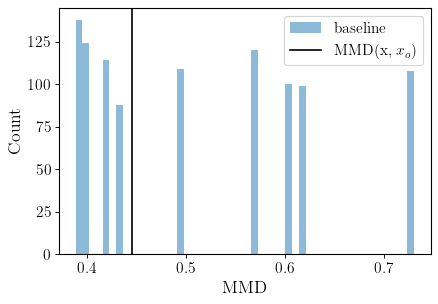

In [14]:
ModelDiagnostics.misspecification_test_mmd(x_sim_long, x_o=x_obs)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)